Image shape: (40, 3000, 2754)
CD20 channel index: 21


C:\Users\jiang\AppData\Local\Temp\ipykernel_14924\2802246555.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  masks[f"class_{c}"] = morphology.remove_small_objects(
C:\Users\jiang\AppData\Local\Temp\ipykernel_14924\2802246555.py:100: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  masks[c] = morphology.remove_s

Saved figure: D:\cycif_segmentation\notebook\otsu_bcell_output\WD-76845-097_auto_top3_otsu_classes.png


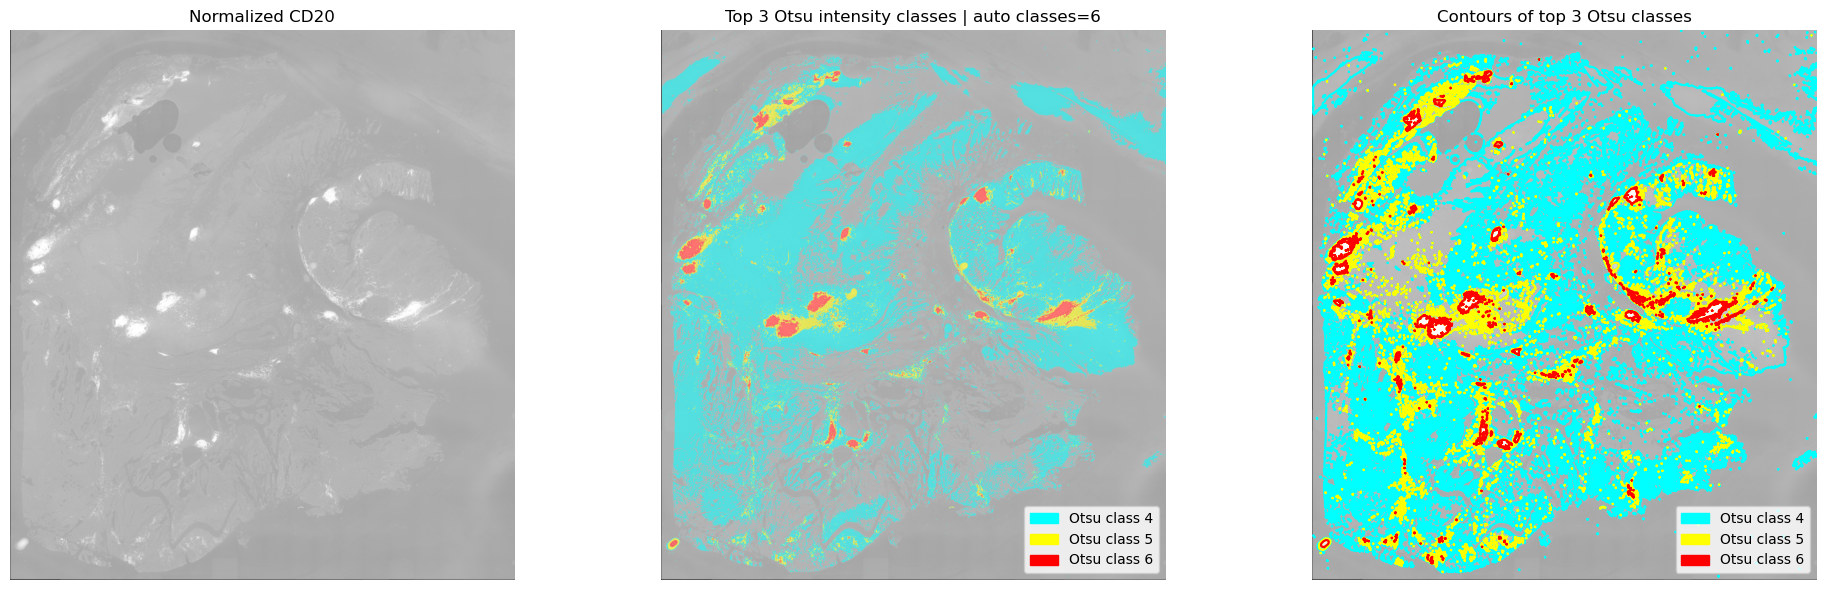

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, tifffile as tif
import matplotlib.pyplot as plt
from skimage import filters, morphology, measure

NOTEBOOK_DIR = Path(r"D:\cycif_segmentation\notebook")
IMG_PATH  = Path(r"D:\cycif_segmentation\raw_download\cycif_segmentation\image\WD-76845-102_3000_channels.ome.tif")
META_PATH = Path(r"D:\cycif_segmentation\raw_download\cycif_segmentation\WD-76845-097-metadata.csv")
OUT_DIR = NOTEBOOK_DIR / "otsu_bcell_output"
OUT_DIR.mkdir(exist_ok=True)

meta = pd.read_csv(META_PATH)
img = np.squeeze(tif.imread(IMG_PATH))   # expected: C, Y, X

def get_channel(marker):
    hit = meta[meta["Marker_Name"].astype(str).str.lower().eq(marker.lower())]
    if len(hit) == 0:
        raise ValueError(f"Marker not found: {marker}")
    return int(hit["Channel_Number"].iloc[0]) - 1   # metadata is 1-based

cd20_raw = img[get_channel("CD20")].astype("float32")
print("Image shape:", img.shape)
print("CD20 channel index:", get_channel("CD20"))

from sklearn.mixture import GaussianMixture

PARAMS = dict(
    smooth_sigma=1,
    class_min=2,
    class_max=7,
    min_pixel_area_each_class=2,   # 原来20，现在更小，保留更细碎/弱信号区域
    top_n_classes=3                # 最后画强度最高的3类
)

def norm01(x):
    x = np.log1p(x)
    lo, hi = np.nanmin(x), np.nanmax(x)
    return (x - lo) / (hi - lo + 1e-6)

def auto_select_classes(x, class_min=2, class_max=7, sample_n=200000):
    """用 GMM+BIC 自动选择 intensity 峰数 / Otsu class 数"""
    vals = x[np.isfinite(x)].ravel()
    vals = vals[(vals > 0) & (vals < 1)]

    if len(vals) > sample_n:
        vals = np.random.choice(vals, sample_n, replace=False)

    vals = vals.reshape(-1, 1)

    bics = []
    ks = range(class_min, class_max + 1)

    for k in ks:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=0
        )
        gmm.fit(vals)
        bics.append(gmm.bic(vals))

    best_k = list(ks)[np.argmin(bics)]
    return best_k, dict(zip(ks, bics))

# normalize + smooth
cd20 = filters.gaussian(
    norm01(cd20_raw),
    sigma=PARAMS["smooth_sigma"]
)

# 自动选择 Otsu class 数
best_classes = 6

# Multi-Otsu
ths = filters.threshold_multiotsu(cd20, classes=best_classes)
class_map = np.digitize(cd20, bins=ths)

# 自动取强度最高的 top N classes
top_n = min(PARAMS["top_n_classes"], best_classes)
top_classes = np.arange(best_classes - top_n, best_classes)

masks = {}
for c in top_classes:
    masks[f"class_{c}"] = morphology.remove_small_objects(
        class_map == c,
        min_size=PARAMS["min_pixel_area_each_class"]
    )


import matplotlib.patches as mpatches
from skimage import measure

# 如果前面还没有生成 masks，就重新生成一次
# class_map label 是 0-based：0最低，best_classes-1最高
top_n = min(PARAMS["top_n_classes"], best_classes)
top_classes = np.arange(best_classes - top_n, best_classes)

masks = {}
for c in top_classes:
    masks[c] = morphology.remove_small_objects(
        class_map == c,
        min_size=PARAMS["min_pixel_area_each_class"]
    )

# 颜色：从低到高 = cyan, yellow, red
color_list = [
    np.array([0.0, 1.0, 1.0]),   # cyan
    np.array([1.0, 1.0, 0.0]),   # yellow
    np.array([1.0, 0.0, 0.0])    # red
]

# 构造 label：显示为 1-based class，方便汇报
plot_items = []
for i, c in enumerate(top_classes):
    label = f"Otsu class {c + 1}"
    plot_items.append((label, masks[c], color_list[i]))

# 构造彩色 overlay
base = np.dstack([cd20, cd20, cd20])
base = base / (base.max() + 1e-6)
overlay = base.copy()

for label, mask, color in plot_items:
    for k in range(3):
        overlay[..., k] = np.where(
            mask,
            0.45 * overlay[..., k] + 0.55 * color[k],
            overlay[..., k]
        )

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1) normalized CD20
ax[0].imshow(cd20, cmap="gray")
ax[0].set_title("Normalized CD20")
ax[0].axis("off")

# 2) top 3 Otsu classes overlay
ax[1].imshow(overlay)
ax[1].set_title(f"Top {top_n} Otsu intensity classes | auto classes={best_classes}")
ax[1].axis("off")

legend_patches = [
    mpatches.Patch(color=color, label=label)
    for label, mask, color in plot_items
]
ax[1].legend(handles=legend_patches, loc="lower right", fontsize=10, frameon=True)

# 3) top 3 classes contours
ax[2].imshow(cd20, cmap="gray")

for label, mask, color in plot_items:
    for contour in measure.find_contours(mask.astype(float), 0.5):
        ax[2].plot(
            contour[:, 1],
            contour[:, 0],
            color=color,
            linewidth=1.5
        )

ax[2].set_title(f"Contours of top {top_n} Otsu classes")
ax[2].axis("off")
ax[2].legend(handles=legend_patches, loc="lower right", fontsize=10, frameon=True)

plt.tight_layout()

fig_path = OUT_DIR / f"WD-76845-097_auto_top{top_n}_otsu_classes.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print("Saved figure:", fig_path)

plt.show()

In [2]:
RED_MIN_AREA = 3
YELLOW_MIN_AREA = 10
CLOSING_PX = 2
BCORE_MIN_AREA = 20

red_raw = class_map == (best_classes - 1)
yellow_raw = class_map == (best_classes - 2)

# Red：去掉1–2 pixel区域
red_mask = morphology.remove_small_objects(
    red_raw,
    min_size=RED_MIN_AREA
)

# Yellow：先连接，再按面积筛选
yellow_mask = morphology.binary_closing(
    yellow_raw,
    morphology.disk(CLOSING_PX)
)
yellow_mask = morphology.remove_small_objects(
    yellow_mask,
    min_size=YELLOW_MIN_AREA
)

# 合并后再次去除零碎B-core候选
b_core = red_mask | yellow_mask
b_core = morphology.remove_small_objects(
    b_core,
    min_size=BCORE_MIN_AREA
)

C:\Users\jiang\AppData\Local\Temp\ipykernel_14924\244521944.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  red_mask = morphology.remove_small_objects(
C:\Users\jiang\AppData\Local\Temp\ipykernel_14924\244521944.py:16: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  yellow_mask = morphology.binary_closing(
C:\Users\jiang\AppData\Local\Temp\ipykernel_14924\244521944.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead.

Saved figure: D:\cycif_segmentation\notebook\otsu_bcell_output\WD-76845-097_bcore_red_yellow_processed_v2.png


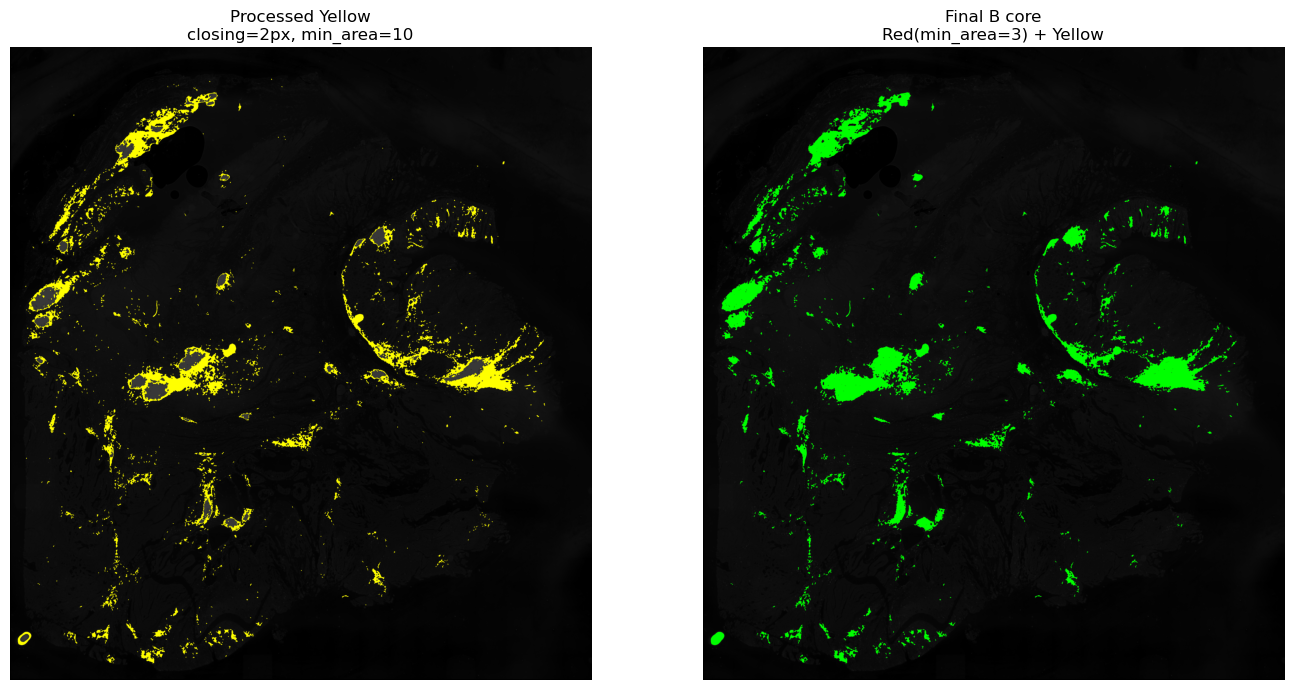

In [3]:
def make_dark_overlay(base_img, mask, color, bg_scale=0.22):
    base = base_img.copy()
    p1, p99 = np.percentile(base[np.isfinite(base)], [1, 99.5])
    base = np.clip((base - p1) / (p99 - p1 + 1e-6), 0, 1)
    base = np.dstack([base, base, base]) * bg_scale

    out = base.copy()
    for k in range(3):
        out[..., k] = np.where(mask, color[k], out[..., k])
    return out

yellow_overlay = make_dark_overlay(cd20, yellow_mask, [1, 1, 0])   # yellow
bcore_overlay  = make_dark_overlay(cd20, b_core,     [0, 1, 0])    # green

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(yellow_overlay)
ax[0].set_title(
    f"Processed Yellow\nclosing={CLOSING_PX}px, min_area={YELLOW_MIN_AREA}"
)
ax[0].axis("off")

ax[1].imshow(bcore_overlay)
ax[1].set_title(f"Final B core\nRed(min_area={RED_MIN_AREA}) + Yellow")
ax[1].axis("off")

plt.tight_layout()

fig_path = OUT_DIR / "WD-76845-097_bcore_red_yellow_processed_v2.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print("Saved figure:", fig_path)

plt.show()

In [4]:
# ============================================================
# 1. CD3/CD4/CD8a density maps
# ============================================================

from scipy import ndimage as ndi

cd3  = img[get_channel("CD3")].astype(np.float32)
cd4  = img[get_channel("CD4")].astype(np.float32)
cd8a = img[get_channel("CD8a")].astype(np.float32)

def density_only(x, sigma=4, bg_percentile=20):
    v = x[np.isfinite(x) & (x > 0)]
    bg = np.percentile(v, bg_percentile)
    return ndi.gaussian_filter(np.maximum(x-bg, 0), sigma=sigma)

D3 = density_only(cd3)
D4 = density_only(cd4)
D8 = density_only(cd8a)

# 必须根据最新 b_core 重新标记
labels = measure.label(b_core, connectivity=2)
print("New B-core objects:", labels.max())

New B-core objects: 722


In [5]:
# ============================================================
# 2. Per-core local T map + T-seeded RSF
# ============================================================

P = dict(
    search_px=100,          # RSF最大搜索距离
    ref_inner=100,          # 局部背景内半径
    ref_outer=150,          # 局部背景外半径
    seed_px=40,             # T seed搜索范围
    seed_q=60,              # 局部T score最高40%作为seed
    local_sigma=12,         # RSF局部拟合尺度
    mu=0.01,                # 弱曲率，减少圆化
    dt=0.3,
    eps=1.5,
    n_iter=120,
    z_floor=-0.5            # 保留少量弱T支持
)

def robust_z(D, ref):
    v = D[ref & np.isfinite(D)]
    if not v.size:
        return np.zeros_like(D, np.float32)

    med = np.median(v)
    mad = np.median(np.abs(v-med))
    scale = 1.4826*mad + max(0.05*med, 1e-6)

    return np.maximum(
        (D-med)/scale - P["z_floor"], 0
    ).astype(np.float32)


def local_T_patch(k):
    core_all = labels == k
    yy, xx = np.where(core_all)
    m = P["ref_outer"]

    sl = np.s_[
        max(0, yy.min()-m):min(labels.shape[0], yy.max()+m+1),
        max(0, xx.min()-m):min(labels.shape[1], xx.max()+m+1)
    ]

    core = core_all[sl]
    dist = ndi.distance_transform_edt(~core)
    ref = (dist >= P["ref_inner"]) & (dist <= P["ref_outer"])

    Z3 = robust_z(D3[sl], ref)
    Z4 = robust_z(D4[sl], ref)
    Z8 = robust_z(D8[sl], ref)

    # CD3 AND (CD4 OR CD8a)
    T = np.sqrt(Z3 * np.maximum(Z4, Z8)).astype(np.float32)
    T[dist > P["ref_outer"]] = 0

    return sl, core, dist, T


def rsf_patch(T, core, dist):
    search = (dist > 0) & (dist <= P["search_px"])
    near   = (dist > 0) & (dist <= P["seed_px"])

    v = T[near & (T > 0)]
    if not v.size:
        return np.zeros_like(core)

    # 不规则T-rich初始化，避免直接膨胀造成圆形边界
    seed = near & (T >= np.percentile(v, P["seed_q"]))
    init = core | seed

    phi = (
        ndi.distance_transform_edt(init) -
        ndi.distance_transform_edt(~init)
    ).astype(np.float32)

    W = (search & ~core).astype(np.float32)

    for _ in range(P["n_iter"]):
        H = 0.5 * (1 + 2/np.pi*np.arctan(phi/P["eps"]))
        delta = P["eps"] / (np.pi*(P["eps"]**2 + phi**2))

        wi, wo = H*W, (1-H)*W

        f1 = ndi.gaussian_filter(T*wi, P["local_sigma"]) / (
            ndi.gaussian_filter(wi, P["local_sigma"]) + 1e-6
        )
        f2 = ndi.gaussian_filter(T*wo, P["local_sigma"]) / (
            ndi.gaussian_filter(wo, P["local_sigma"]) + 1e-6
        )

        data = (T-f2)**2 - (T-f1)**2

        gy, gx = np.gradient(phi)
        mag = np.sqrt(gx**2 + gy**2 + 1e-8)
        curv = (
            np.gradient(gx/mag, axis=1) +
            np.gradient(gy/mag, axis=0)
        )

        phi += P["dt"]*delta*(data + P["mu"]*curv)

        # 搜索范围外固定为外部，B core固定为内部
        phi[~(search | core)] = -np.abs(phi[~(search | core)])
        phi[core] = np.abs(phi[core])

    return (phi >= 0) & ~core

In [6]:
# ============================================================
# 3. Run RSF
# ============================================================

RUN_FULL_IMAGE = False

if RUN_FULL_IMAGE:
    crop = np.s_[:, :]
    core_ids = np.arange(1, labels.max()+1)
else:
    # notebook原来的分析区域
    x0, x1 = 1000, 2200
    y0, y1 = 1300, 2000
    crop = np.s_[y0:y1, x0:x1]

    core_ids = np.unique(labels[crop])
    core_ids = core_ids[core_ids > 0]

merged_T = np.zeros_like(b_core, bool)
T_map = np.zeros_like(D3, np.float32)

for i, k in enumerate(core_ids, 1):
    sl, core_p, dist_p, T_p = local_T_patch(k)
    result_p = rsf_patch(T_p, core_p, dist_p)

    merged_T[sl] |= result_p
    np.maximum(T_map[sl], T_p, out=T_map[sl])

    print(f"\rRSF: {i}/{len(core_ids)}", end="")

print("\nRaw RSF pixels:", merged_T[crop].sum())

RSF: 143/143
Raw RSF pixels: 139039


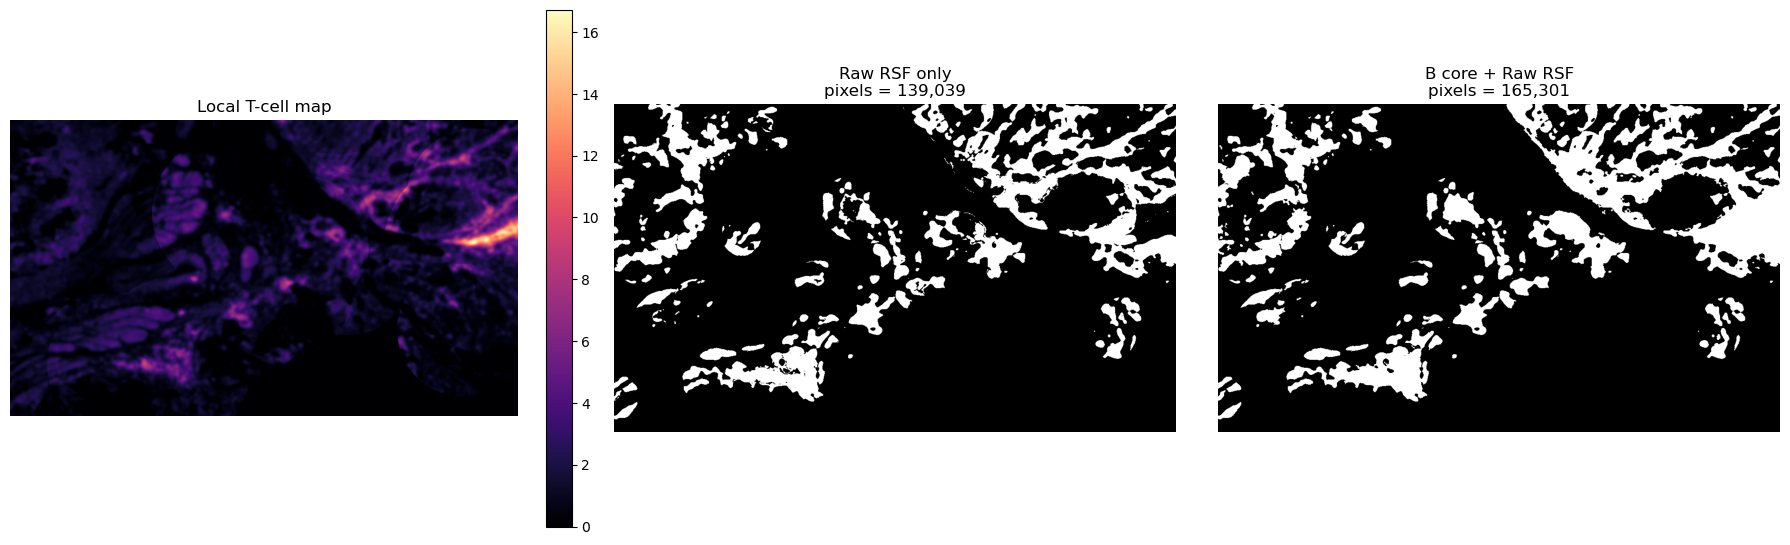

In [9]:
# ============================================================
# 4. Visualize raw RSF result before filtering
# ============================================================

raw_rsf = merged_T
raw_tls = b_core | merged_T

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 1. 原始T-map
im = ax[0].imshow(T_map[crop], cmap="magma")
ax[0].set_title("Local T-cell map")
plt.colorbar(im, ax=ax[0], fraction=0.046)

# 2. RSF向外生长部分，不包含B core
ax[1].imshow(raw_rsf[crop], cmap="gray")
ax[1].set_title(f"Raw RSF only\npixels = {raw_rsf[crop].sum():,}")

# 3. B core + 原始RSF
ax[2].imshow(raw_tls[crop], cmap="gray")
ax[2].set_title(f"B core + Raw RSF\npixels = {raw_tls[crop].sum():,}")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 4. T-constrained merging + signed-distance smoothing
# ============================================================

rsf0 = merged_T[crop].copy()
T0   = T_map[crop]
B0   = b_core[crop]

# 只有存在局部T支持的像素允许连接
allowed = T0 > 0

# 沿T支持区域最多生长6 px
rsf_merge = rsf0.copy()
for _ in range(10):
    rsf_merge |= ndi.binary_dilation(rsf_merge) & allowed

# signed-distance平滑，sigma=1.5
phi_s = (
    ndi.distance_transform_edt(rsf_merge) -
    ndi.distance_transform_edt(~rsf_merge)
)
rsf_smooth = ndi.gaussian_filter(phi_s, sigma=1.5) > 0
rsf_smooth = rsf0 | (rsf_smooth & allowed)

# 加回B core，只保留与B core相连的连通区域
combined = rsf_smooth | B0
lab = measure.label(combined, connectivity=2)

keep_ids = np.unique(lab[B0])
keep_ids = keep_ids[keep_ids > 0]

tls_crop = np.isin(lab, keep_ids) | B0

# 放回整张图
tls_rsf = np.zeros_like(b_core, bool)
tls_rsf[crop] = tls_crop

print("Final TLS pixels:", tls_crop.sum())
print("Final TLS objects:", measure.label(tls_crop).max())

Final TLS pixels: 301037
Final TLS objects: 15


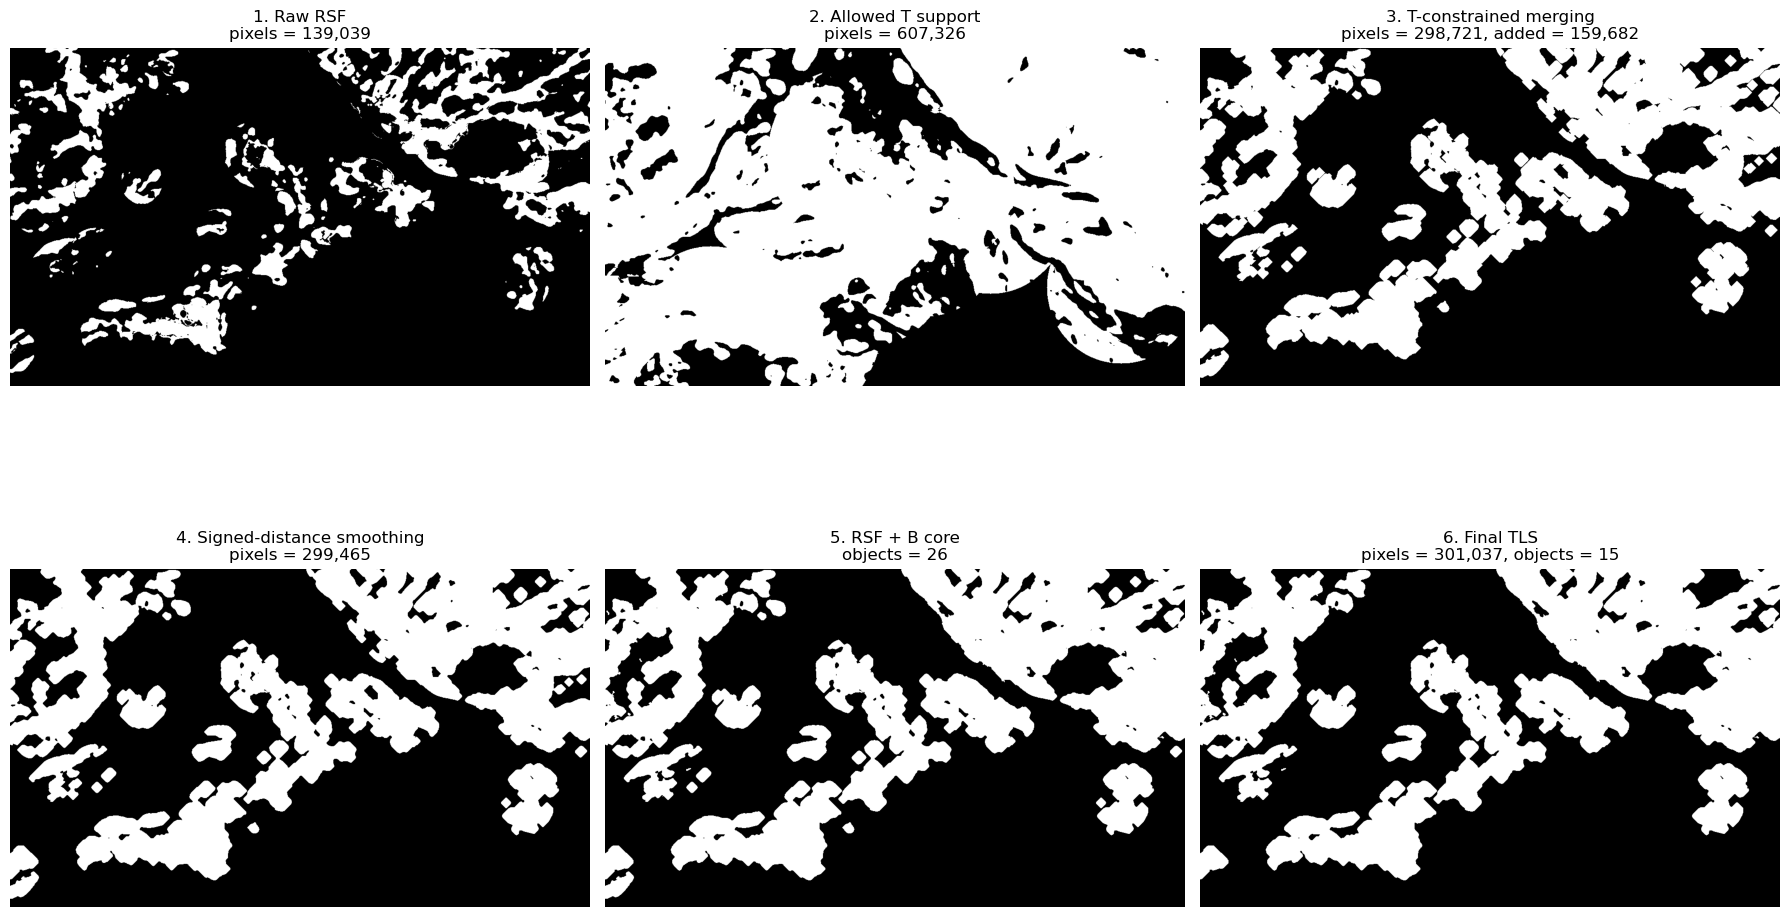

In [13]:
# ============================================================
# 5. Visualize merging and smoothing results
# ============================================================

fig, ax = plt.subplots(2, 3, figsize=(18, 12))

# 1. 原始RSF
ax[0, 0].imshow(rsf0, cmap="gray")
ax[0, 0].set_title(f"1. Raw RSF\npixels = {rsf0.sum():,}")

# 2. 允许生长的T支持区域
ax[0, 1].imshow(allowed, cmap="gray")
ax[0, 1].set_title(f"2. Allowed T support\npixels = {allowed.sum():,}")

# 3. 沿T区域连接后的RSF
ax[0, 2].imshow(rsf_merge, cmap="gray")
ax[0, 2].set_title(
    f"3. T-constrained merging\n"
    f"pixels = {rsf_merge.sum():,}, "
    f"added = {(rsf_merge & ~rsf0).sum():,}"
)

# 4. signed-distance平滑后
ax[1, 0].imshow(rsf_smooth, cmap="gray")
ax[1, 0].set_title(
    f"4. Signed-distance smoothing\n"
    f"pixels = {rsf_smooth.sum():,}"
)

# 5. 加回B core
ax[1, 1].imshow(combined, cmap="gray")
ax[1, 1].set_title(
    f"5. RSF + B core\n"
    f"objects = {lab.max()}"
)

# 6. 最终与B core相连的TLS
ax[1, 2].imshow(tls_crop, cmap="gray")
ax[1, 2].set_title(
    f"6. Final TLS\n"
    f"pixels = {tls_crop.sum():,}, "
    f"objects = {measure.label(tls_crop, connectivity=2).max()}"
)

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

Raw RSF objects: 175
Objects after merging and smoothing: 69
Objects after adding B cores: 63
Final objects connected to red B cores: 8
Final TLS pixels: 205963
Saved figure: D:\cycif_segmentation\notebook\otsu_bcell_output\WD-76845-097_RSF_merge_then_red_core_filter.png


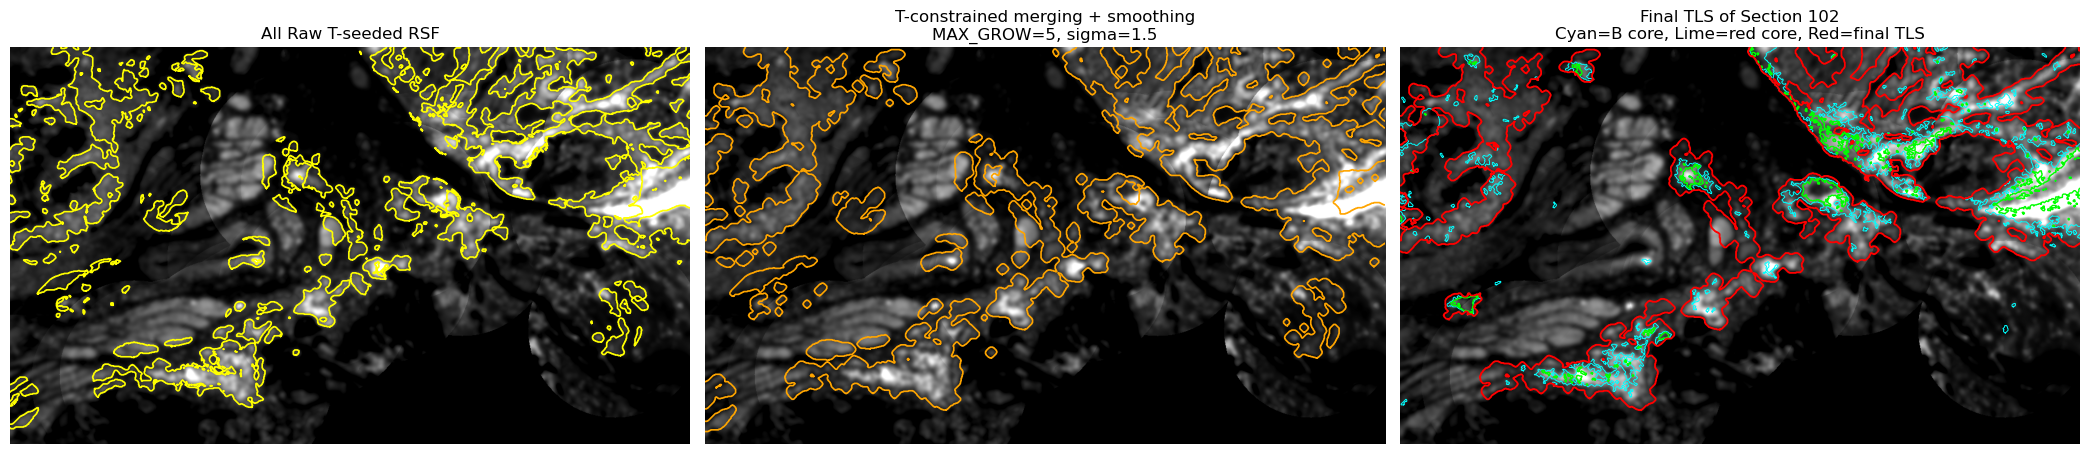

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import measure

# ============================================================
# 1. Select plotting ROI
# ============================================================

x0, x1 = 1000, 2200
y0, y1 = 1300, 2000
crop = np.s_[y0:y1, x0:x1]

raw0 = merged_T[crop].copy()  # 全部Raw RSF，不含B core
T0   = T_map[crop]
B0   = b_core[crop]
R0   = red_mask[crop]

# 明确限定为B core内部的Class red
red_core0 = R0 & B0


# ============================================================
# 2. Merge all Raw RSF in T-supported regions
# ============================================================

MAX_GROW =5
allowed = T0 > 0

rsf_merge = raw0.copy()

for _ in range(MAX_GROW):
    grow = ndi.binary_dilation(rsf_merge)
    rsf_merge |= grow & allowed


# ============================================================
# 3. Signed-distance smoothing
# ============================================================

phi_s = (
    ndi.distance_transform_edt(rsf_merge) -
    ndi.distance_transform_edt(~rsf_merge)
)

smooth_candidate = (
    ndi.gaussian_filter(phi_s, sigma=1.5) > 0
)

# 原始Raw RSF必须保留；平滑新增区域必须有T支持
rsf_smooth = raw0 | (smooth_candidate & allowed)


# ============================================================
# 4. Add B cores, then retain components connected to red cores
# ============================================================

combined = rsf_smooth | B0
lab = measure.label(combined, connectivity=2)

# 找到包含red B core的连通区域
keep_ids = np.unique(lab[red_core0])
keep_ids = keep_ids[keep_ids > 0]

tls_crop = np.isin(lab, keep_ids)


# ============================================================
# 5. Put result back into full image
# ============================================================

tls_rsf = np.zeros_like(b_core, dtype=bool)
tls_rsf[crop] = tls_crop

print(
    "Raw RSF objects:",
    measure.label(raw0, connectivity=2).max()
)
print(
    "Objects after merging and smoothing:",
    measure.label(rsf_smooth, connectivity=2).max()
)
print(
    "Objects after adding B cores:",
    lab.max()
)
print(
    "Final objects connected to red B cores:",
    measure.label(tls_crop, connectivity=2).max()
)
print(
    "Final TLS pixels:",
    tls_crop.sum()
)


# ============================================================
# 6. Visualization
# ============================================================

positive = T0[T0 > 0]
tmax = np.percentile(positive, 99) if positive.size else 1

fig, ax = plt.subplots(1, 3, figsize=(21, 7))

# ---------- 1. Raw RSF ----------
ax[0].imshow(T0, cmap="gray", vmin=0, vmax=tmax)

for c in measure.find_contours(raw0.astype(float), 0.5):
    ax[0].plot(c[:, 1], c[:, 0], color="yellow", lw=1.2)

ax[0].set_title("All Raw T-seeded RSF")


# ---------- 2. Merged + smoothed RSF ----------
ax[1].imshow(T0, cmap="gray", vmin=0, vmax=tmax)

for c in measure.find_contours(rsf_smooth.astype(float), 0.5):
    ax[1].plot(c[:, 1], c[:, 0], color="orange", lw=1.2)

ax[1].set_title(
    "T-constrained merging + smoothing\n"
    f"MAX_GROW={MAX_GROW}, sigma=1.5"
)


# ---------- 3. Final result ----------
ax[2].imshow(T0, cmap="gray", vmin=0, vmax=tmax)

# 全部B core：cyan
for c in measure.find_contours(B0.astype(float), 0.5):
    ax[2].plot(c[:, 1], c[:, 0], color="cyan", lw=0.7)

# red B core：lime
for c in measure.find_contours(red_core0.astype(float), 0.5):
    ax[2].plot(c[:, 1], c[:, 0], color="lime", lw=1)

# 最终TLS：red
for c in measure.find_contours(tls_crop.astype(float), 0.5):
    ax[2].plot(c[:, 1], c[:, 0], color="red", lw=1.3)

ax[2].set_title(
    "Final TLS of Section 102\n"
    "Cyan=B core, Lime=red core, Red=final TLS"
)

for a in ax:
    a.axis("off")

plt.tight_layout()

fig_path = OUT_DIR / "WD-76845-097_RSF_merge_then_red_core_filter.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure:", fig_path)
plt.show()